# Projeto de Clustering: Segmentação de Clientes de Shopping

### Aluno: Davi Cardoso de Oliveira
### link do vídeo: https://youtu.be/KBa_jLVjD_g

## Contexto do Problema
O objetivo deste projeto é explorar um conjunto de dados contendo informações sobre clientes de um shopping center.

A meta é utilizar um algoritmo de clustering (K-Means) para identificar perfis de consumo distintos. Isso permitirá que a equipe de marketing entenda melhor seu público (ex: quem gasta muito e ganha pouco, quem é economizador, etc.) e direcione campanhas específicas.

### Importação de bibliotecas
Abaixo, importamos as bibliotecas necessárias para manipulação de dados, visualização e modelagem.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import silhouette_score

url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"

print("Bibliotecas importadas e URL definida.")

Bibliotecas importadas e URL definida.


## Dados
O dataset contém as seguintes variáveis:

* `CustomerID`: ID do cliente (será removido pois não agrega valor preditivo).
* `Gender`: Gênero do cliente.
* `Age`: Idade do cliente.
* `Annual Income (k$)`: Renda anual em milhares de dólares.
* `Spending Score (1-100)`: Pontuação atribuída pelo shopping com base no comportamento de gastos (quanto maior, mais gasta).

In [ ]:
df = pd.read_csv(url)

# Renomeando colunas
df.rename(columns={
    'Annual Income (k$)': 'Income',
    'Spending Score (1-100)': 'Score'
}, inplace=True)

df.head()

,CustomerID,Gender,Age,Income,Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Análise e tratamento dos dados
Verificando os tipos de dados, estatísticas descritivas e procurar por valores nulos.

In [ ]:
print("Informações gerais do dataset:")
print(df.info())

print("\n\nEstatísticas descritivas:")
df.describe().T

Informações gerais do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CustomerID  200 non-null    int64 
 1   Gender      200 non-null    object
 2   Age         200 non-null    int64 
 3   Income      200 non-null    int64 
 4   Score       200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


Estatísticas descritivas:


,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Income,200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Score,200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


A coluna `CustomerID` não é uma característica comportamental, é apenas um identificador. Vamos removê-la. Também verificaremos valores nulos.

In [ ]:
# Removendo ID
if 'CustomerID' in df.columns:
    df.drop('CustomerID', axis=1, inplace=True)

print("Valores faltantes:")
print(df.isna().sum())

# Codificando a variável categórica 'Gender'
# 0 = Female, 1 = Male (dependendo da ordem alfabética do LabelEncoder)
encoder = LabelEncoder()
df['Gender'] = encoder.fit_transform(df['Gender'])

print("\nDataset após tratamento:")
df.head()

Valores faltantes:
Gender    0
Age       0
Income    0
Score     0
dtype: int64

Dataset após tratamento:


,Gender,Age,Income,Score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


Verificando a distribuição dos dados e a presença de outliers, especialmente na Renda (Income) e na Idade.

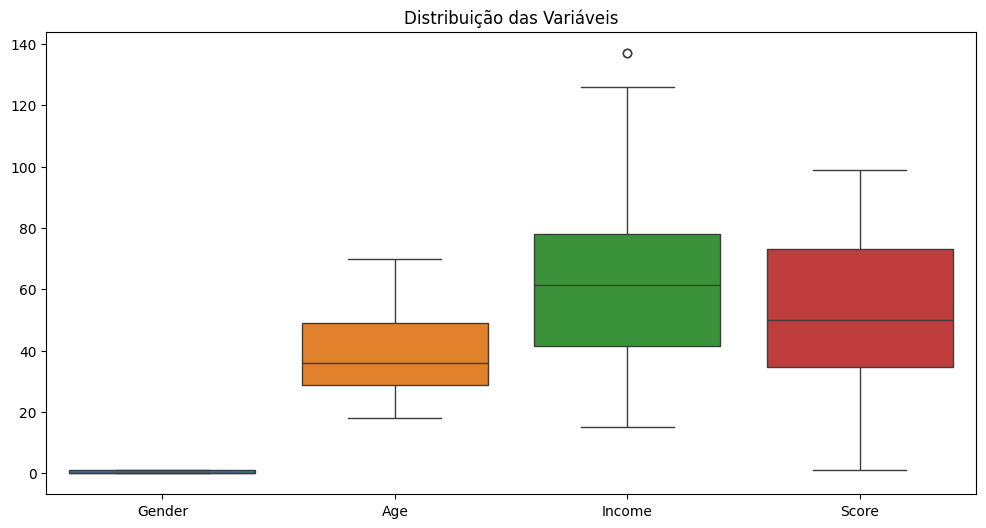

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.title("Distribuição das Variáveis")
plt.show()

Como o K-Means utiliza a distância Euclidiana, é crucial que todas as variáveis estejam na mesma escala. Usando o `MinMaxScaler` para colocar tudo entre 0 e 1.

In [ ]:
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
df_scaled.head()

,Gender,Age,Income,Score
0,1.0,0.019231,0.000000,0.387755
1,1.0,0.057692,0.000000,0.816327
2,0.0,0.038462,0.008197,0.051020
3,0.0,0.096154,0.008197,0.775510
4,0.0,0.250000,0.016393,0.397959


## PCA
Assim como no projeto dos pinguins, usaremos o PCA para reduzir a dimensionalidade. Embora tenhamos poucas colunas, o PCA ajuda a visualizar os clusters em um gráfico 2D e a capturar a variância principal.

In [ ]:
# Reduzindo para 2 componentes para facilitar a visualização
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

print(f"Variância explicada pelos 2 componentes: {pca.explained_variance_ratio_.sum():.2%}")

Variância explicada pelos 2 componentes: 78.48%


## Método do Cotovelo (Elbow Method)
Testando de 1 a 10 clusters para encontrar o ponto de inflexão ideal.

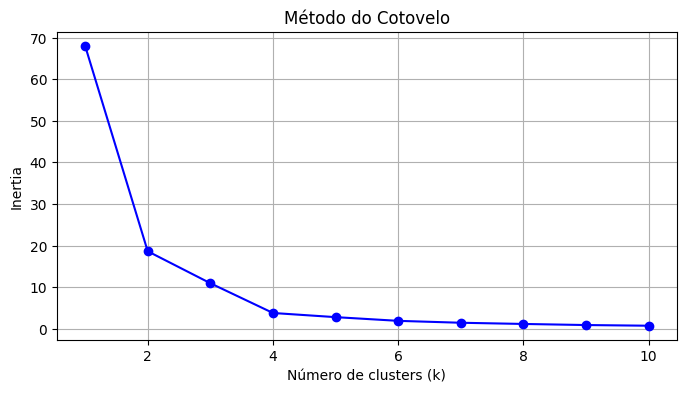

In [ ]:
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), sse, 'bo-', markersize=6)
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inertia")
plt.title("Método do Cotovelo")
plt.grid(True)
plt.show()

## Método da Silhueta
Para confirmar a escolha do Cotovelo (que geralmente sugere 5 para este dataset), vamos olhar o score da silhueta.

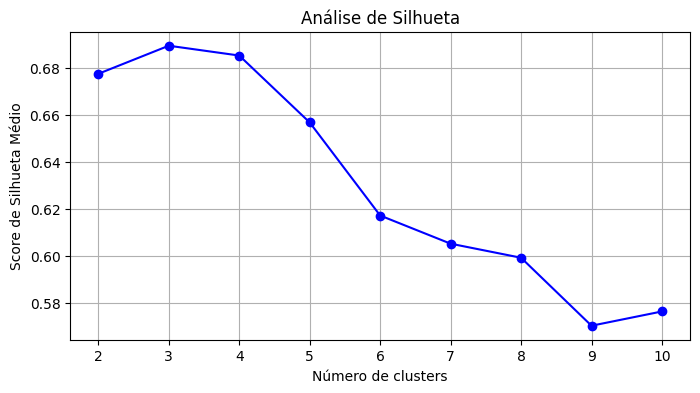

Número de clusters escolhido: 5


In [ ]:
silhouette_avg_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_pca)
    silhouette_avg = silhouette_score(df_pca, cluster_labels)
    silhouette_avg_scores.append(silhouette_avg)

plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_avg_scores, 'bo-', markersize=6)
plt.xlabel("Número de clusters")
plt.ylabel("Score de Silhueta Médio")
plt.title("Análise de Silhueta")
plt.grid(True)
plt.show()

# Definindo o melhor K
best_k = 5
print(f"Número de clusters escolhido: {best_k}")

## Aplicação do Modelo
Executando o K-Means com o número escolhido de clusters e analisando as médias de cada grupo.

In [ ]:
# Treinando o modelo final
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(df_pca)

# Adicionando os labels ao dataframe original (não o escalonado) para interpretação real
df_interpret = df.copy()
df_interpret['Cluster'] = cluster_labels
cluster_profiles = df_interpret.groupby('Cluster').mean()
cluster_profiles['Count'] = df_interpret['Cluster'].value_counts()

cluster_profiles

,Gender,Age,Income,Score,Count
Cluster,,,,,
0,1.0,49.437500,62.416667,29.208333,48
1,0.0,40.625000,57.875000,41.175000,40
2,1.0,28.250000,62.000000,71.675000,40
3,0.0,53.833333,58.833333,26.666667,24
4,0.0,28.125000,60.604167,72.583333,48


## Interpretação Visual
O Heatmap abaixo mostra as características normalizadas de cada cluster. Cores mais claras indicam valores altos naquela característica.

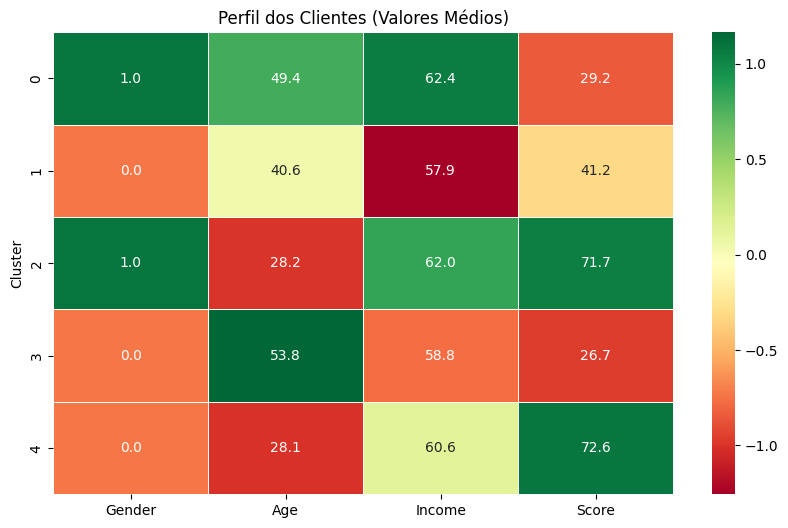

In [ ]:
# Normalizando apenas para visualização no heatmap
cluster_profiles_normalized = cluster_profiles.drop(columns=['Count']).apply(lambda x: (x - x.mean()) / x.std())

plt.figure(figsize=(10, 6))
sns.heatmap(
    cluster_profiles_normalized,
    annot=cluster_profiles.drop(columns=['Count']),
    fmt=".1f",
    cmap="RdYlGn",
    linewidths=0.5
)
plt.title("Perfil dos Clientes (Valores Médios)")
plt.show()

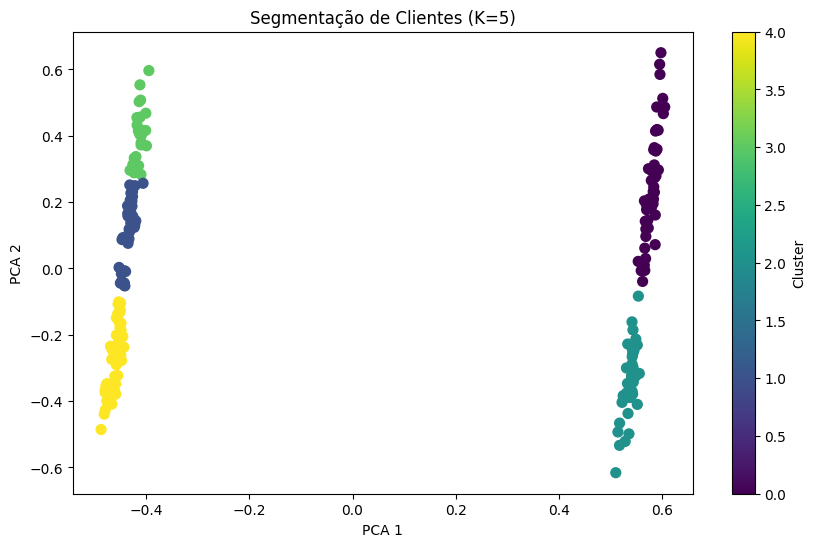

In [ ]:
# Visualizando a dispersão dos grupos nos componentes principais
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=cluster_labels, cmap='viridis', s=50)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title(f"Segmentação de Clientes (K={best_k})")
plt.colorbar(scatter, label='Cluster')
plt.show()

## Conclusões e Perfis Encontrados

Ao analisar a tabela de médias e o heatmap, geralmente encontramos 5 perfis bem distintos neste dataset (a numeração dos clusters pode variar a cada execução, mas os perfis são consistentes):

1.  **Gastadores (Score alto, Renda alta):** O público alvo 'Premium'. Têm dinheiro e gostam de gastar.
2.  **Poupadores (Score baixo, Renda alta):** Ganham bem, mas gastam pouco. Potencial a ser trabalhado.
3.  **Prudentes (Score baixo, Renda baixa):** Ganham pouco e gastam pouco.
4.  **Imprudentes/Fãs (Score alto, Renda baixa):** Ganham pouco, mas compram muito. Atenção ao crédito.
5.  **Média (Score médio, Renda média):** O público padrão do shopping.

#### Próximos Passos
A equipe de marketing poderia criar uma campanha de luxo para o grupo "Gastadores" e uma campanha de descontos ou liquidação para o grupo "Média" ou "Imprudentes".